# Project: "Read the Room" - Facial Expression Recognition for Online Meetings

**The Question:** Can a simple Computer Vision model provide "live feedback" to an interviewer by classifying the facial expressions of a candidate?

**The Goal:** We will build a Convolutional Neural Network (CNN) to classify faces from the FER2013 dataset into 7 emotions, and then aggregate them into a **"Sentiment Score"** (Positive/Negative/Neutral) to visualize how a conversation is trending over time.

**The Dataset:** [FER2013](https://www.kaggle.com/datasets/msambare/fer2013) (Facial Expression Recognition 2013). 48x48 pixel grayscale images of faces.

## Import Libraries
Importing necessary libraries for data handling, visualization, and model building.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
import kagglehub
import cv2

# Check for GPU
print("GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)

# --- Kaggle API Key Setup ---
print("\n--- Kaggle API Key Setup ---")
if os.path.exists('kaggle.json'):
    dest_dir = os.path.expanduser('~/.kaggle')
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
    print(f"Ensure kaggle.json is in {dest_dir} for authentication.")
else:
    print("Warning: 'kaggle.json' not found. Kaggle downloads may fail.")

# --- Dataset Download Logic ---
dataset_downloaded_successfully = False
path = None

print("\n--- Dataset Download ---")
try:
    path = kagglehub.dataset_download("msambare/fer2013")
    print(f"Dataset downloaded and extracted by KaggleHub to: {path}")
    dataset_downloaded_successfully = True
except Exception as e:
    print(f"KaggleHub download failed: {e}")
    if os.path.exists('fer2013'):
        path = 'fer2013'
        dataset_downloaded_successfully = True
        print("Using local 'fer2013' folder.")

if dataset_downloaded_successfully and path:
    print(f"\nDataset setup complete. Base directory for images: {path}")
    train_dir = os.path.join(path, 'train')
    test_dir = os.path.join(path, 'test')
    print(f'Train dir: {train_dir}, Test dir: {test_dir}')
else:
    print("\nFailed to download or find FER2013 dataset.")

from tensorflow.keras.models import load_model

GPU Available:  False

--- Kaggle API Key Setup ---

--- Dataset Download ---
Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded and extracted by KaggleHub to: /kaggle/input/fer2013

Dataset setup complete. Base directory for images: /kaggle/input/fer2013
Train dir: /kaggle/input/fer2013/train, Test dir: /kaggle/input/fer2013/test


## Data Preparation
Defining constants and downloading the dataset.

In [ ]:
# Constants
IMG_HEIGHT, IMG_WIDTH = 48, 48
BATCH_SIZE = 64

# --- Data Generators ---

# 1. Grayscale Generators (for Dense & CNN Baselines)
train_datagen_gray = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen_gray = ImageDataGenerator(rescale=1./255)

print("Loading Data (Grayscale for Baselines)...")
train_generator_gray = train_datagen_gray.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=True
)
validation_generator_gray = val_datagen_gray.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=False
)

# 2. RGB Generators (for ResNet50)
train_datagen_rgb = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen_rgb = ImageDataGenerator(rescale=1./255)

print("Loading Data (RGB for ResNet50)...")
train_generator_rgb = train_datagen_rgb.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=True
)
validation_generator_rgb = val_datagen_rgb.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
print("Calculating Class Weights...")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator_gray.classes),
    y=train_generator_gray.classes
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weights_dict}")


Loading Data (Grayscale for Baselines)...
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Loading Data (RGB for ResNet50)...
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Calculating Class Weights...
Class Weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


## Data Visualization
Visualizing sample images from the dataset to verify preprocessing.

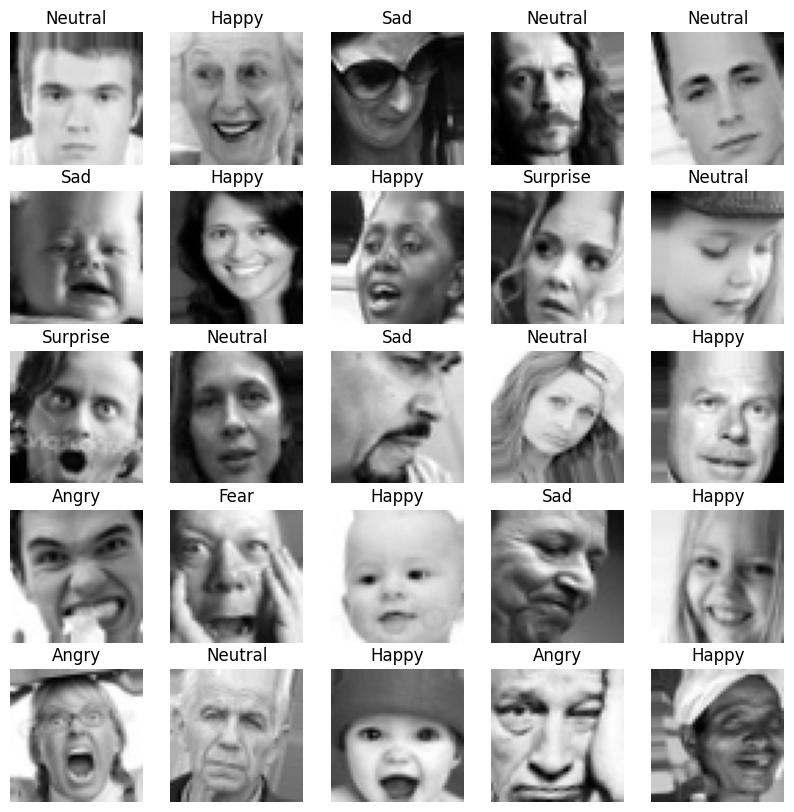

In [ ]:
# Get a batch of images
sample_imgs, sample_labels = next(train_generator_gray)
emotion_dict = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Neutral', 5: 'Sad', 6: 'Surprise'}

# Plot a 5x5 grid
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(sample_imgs[i].reshape(48, 48), cmap='gray')
    label_index = np.argmax(sample_labels[i])
    plt.title(emotion_dict[label_index])
    plt.axis('off')
plt.show()

## Dense Baseline Model
Defining and training a simple Dense network (MLP) as a baseline model. It takes flattened images as input.

In [ ]:
model_dense = Sequential([
    Flatten(input_shape=(48, 48, 1)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(7, activation='softmax') # 7 Emotions
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Baseline Dense Model...")
history_dense = model_dense.fit(train_generator_gray, epochs=5, validation_data=validation_generator_gray, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Baseline Dense Model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 227ms/step - accuracy: 0.2291 - loss: 1.9036 - val_accuracy: 0.2644 - val_loss: 1.7875
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.2702 - loss: 1.7844 - val_accuracy: 0.3348 - val_loss: 1.7296
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.2898 - loss: 1.7572 - val_accuracy: 0.3214 - val_loss: 1.7299
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.2896 - loss: 1.7567 - val_accuracy: 0.3348 - val_loss: 1.7024
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.2904 - loss: 1.7502 - val_accuracy: 0.3232 - val_loss: 1.7007


In [ ]:
# --- model_dense (Save/Load Logic) ---
model_filename = 'model_dense.keras'

if os.path.exists(model_filename):
    print(f"Loading saved model: {model_filename}...")
    model_dense = load_model(model_filename)
    # Create a dummy history object if loading, so plotting doesn't fail
    class DummyHistory:
        def __init__(self):
            self.history = {'val_accuracy': [0], 'val_loss': [0], 'accuracy': [0], 'loss': [0]}
    history_dense = DummyHistory()
else:
    print(f"Training {model_filename}...")

    model_dense = Sequential([
        Flatten(input_shape=(48, 48, 1)),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])

    model_dense.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

    history_dense = model_dense.fit(
        train_generator_gray,
        epochs=20,
        validation_data=validation_generator_gray,
        class_weight=class_weights_dict,
        verbose=1
    )


    print(f"Saving model to {model_filename}...")
    model_dense.save(model_filename)


Training model_dense.keras...
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.1178 - loss: 2.1616 - val_accuracy: 0.1523 - val_loss: 1.9399
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.1659 - loss: 1.9394 - val_accuracy: 0.1431 - val_loss: 1.9451
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.1494 - loss: 1.9358 - val_accuracy: 0.1333 - val_loss: 1.9499
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.1161 - loss: 1.9260 - val_accuracy: 0.0157 - val_loss: 1.9490
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.0596 - loss: 1.9495 - val_accuracy: 0.0160 - val_loss: 1.9479
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.0996 - loss: 1.9434 - val_accuracy: 0.0157 - val_loss: 1.9469
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.1336 - loss: 1.9415 - val_accuracy: 0.1739 - val_loss: 1.9470
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accu

## CNN Model
Defining a Convolutional Neural Network (CNN) with Batch Normalization and Dropout layers for better feature extraction.

In [ ]:
# --- model_cnn (Save/Load Logic) ---
model_filename = 'model_cnn.keras'

if os.path.exists(model_filename):
    print(f"Loading saved model: {model_filename}...")
    model_cnn = load_model(model_filename)
    # Create a dummy history object if loading, so plotting doesn't fail
    class DummyHistory:
        def __init__(self):
            self.history = {'val_accuracy': [0], 'val_loss': [0], 'accuracy': [0], 'loss': [0]}
    history_cnn = DummyHistory()
else:
    print(f"Training {model_filename}...")

    model_cnn = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Fully Connected
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])

    model_cnn.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    # Callbacks for CNN
    early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr_cnn = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)

    history_cnn = model_cnn.fit(
        train_generator_gray,
        epochs=20,
        validation_data=validation_generator_gray,
        callbacks=[early_stopping_cnn, reduce_lr_cnn],
        class_weight=class_weights_dict,
        verbose=1
    )


    print(f"Saving model to {model_filename}...")
    model_cnn.save(model_filename)

Training model_cnn.keras...
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 56s 102ms/step - accuracy: 0.1673 - loss: 2.5560 - val_accuracy: 0.1595 - val_loss: 1.9490 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.2224 - loss: 1.9590 - val_accuracy: 0.3408 - val_loss: 1.7079 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.2756 - loss: 1.8024 - val_accuracy: 0.2120 - val_loss: 2.0042 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.3095 - loss: 1.7305 - val_accuracy: 0.4319 - val_loss: 1.5461 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.3549 - loss: 1.6443 - val_accuracy: 0.3406 - val_loss: 1.7163 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.3676 - loss: 1.6261 - val_accuracy: 0.4133 - val_loss: 1.6056 - learning_rate: 0.0010
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 84m

## Create Data Generators with No Augmentation


Modify the ImageDataGenerator configurations for both grayscale and RGB images to disable all augmentation parameters (e.g., `rotation_range`, `width_shift_range`, `zoom_range`, `horizontal_flip`), retaining only `rescale=1./255`. This will create new `train_generator_gray_no_aug`, `validation_generator_gray_no_aug`, `train_generator_rgb_no_aug`, and `validation_generator_rgb_no_aug`.


In [ ]:
print("\n--- Creating Data Generators with Minimal Augmentation ---")

# 1. Grayscale Generators (No Augmentation)
train_datagen_gray_no_aug = ImageDataGenerator(rescale=1./255)
val_datagen_gray_no_aug = ImageDataGenerator(rescale=1./255)

print("Loading Data (Grayscale, No Augmentation)...")
train_generator_gray_no_aug = train_datagen_gray_no_aug.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=True
)
print("train_generator_gray_no_aug created.")

validation_generator_gray_no_aug = val_datagen_gray_no_aug.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=False
)
print("validation_generator_gray_no_aug created.")

# 2. RGB Generators (No Augmentation)
train_datagen_rgb_no_aug = ImageDataGenerator(rescale=1./255)
val_datagen_rgb_no_aug = ImageDataGenerator(rescale=1./255)

print("Loading Data (RGB, No Augmentation)...")
train_generator_rgb_no_aug = train_datagen_rgb_no_aug.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=True
)
print("train_generator_rgb_no_aug created.")

validation_generator_rgb_no_aug = val_datagen_rgb_no_aug.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False
)
print("validation_generator_rgb_no_aug created.")


--- Creating Data Generators with Minimal Augmentation ---
Loading Data (Grayscale, No Augmentation)...
Found 28709 images belonging to 7 classes.
train_generator_gray_no_aug created.
Found 7178 images belonging to 7 classes.
validation_generator_gray_no_aug created.
Loading Data (RGB, No Augmentation)...
Found 28709 images belonging to 7 classes.
train_generator_rgb_no_aug created.
Found 7178 images belonging to 7 classes.
validation_generator_rgb_no_aug created.



The next step is to retrain a Convolutional Neural Network (CNN) model using the newly created grayscale data generators without augmentation, based on the architecture from cell `f_U_HD9uetcY`, and store its training history as `history_cnn_no_aug`.



In [ ]:
model_filename_cnn_no_aug = 'model_cnn_no_aug.keras'

if os.path.exists(model_filename_cnn_no_aug):
    print(f"Loading saved model: {model_filename_cnn_no_aug}...")
    model_cnn_no_aug = load_model(model_filename_cnn_no_aug)
    class DummyHistory:
        def __init__(self):
            self.history = {'val_accuracy': [0], 'val_loss': [0], 'accuracy': [0], 'loss': [0]}
    history_cnn_no_aug = DummyHistory()
else:
    print(f"Training {model_filename_cnn_no_aug} (no augmentation)...")

    model_cnn_no_aug = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Fully Connected
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])

    model_cnn_no_aug.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    early_stopping_cnn_no_aug = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr_cnn_no_aug = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6)

    history_cnn_no_aug = model_cnn_no_aug.fit(
        train_generator_gray_no_aug,
        epochs=20,
        validation_data=validation_generator_gray_no_aug,
        callbacks=[early_stopping_cnn_no_aug, reduce_lr_cnn_no_aug],
        class_weight=class_weights_dict,
        verbose=1
    )

    print(f"Saving model to {model_filename_cnn_no_aug}...")
    model_cnn_no_aug.save(model_filename_cnn_no_aug)

Training model_cnn_no_aug.keras (no augmentation)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 123ms/step - accuracy: 0.2006 - loss: 2.4290 - val_accuracy: 0.2026 - val_loss: 2.0443 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.3221 - loss: 1.7314 - val_accuracy: 0.3019 - val_loss: 1.8787 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.3920 - loss: 1.5506 - val_accuracy: 0.4515 - val_loss: 1.4429 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.4312 - loss: 1.4503 - val_accuracy: 0.4851 - val_loss: 1.3535 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.4418 - loss: 1.4011 - val_accuracy: 0.4873 - val_loss: 1.3509 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.4607 - loss: 1.3644 - val_accuracy: 0.4622 - val_loss: 1.4210 - learning_rate: 0.0010
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.4712 - 

## ResNet50 Model
Using Transfer Learning with the ResNet50 architecture. The pre-trained backbone is fine-tuned on our dataset.

In [ ]:
# Train ResNet50 with RGB data + augmentation
model_filename_resnet_aug = 'model_resnet_aug.keras'
best_model_checkpoint_filename_aug = 'best_model_resnet_aug.keras'

if os.path.exists(model_filename_resnet_aug):
    print(f"Loading saved model: {model_filename_resnet_aug}...")
    model_resnet_1e3_aug = load_model(model_filename_resnet_aug)

    # Dummy history so later plotting code doesn't break
    class DummyHistory:
        def __init__(self):
            self.history = {
                'val_accuracy': [0],
                'val_loss': [0],
                'accuracy': [0],
                'loss': [0]
            }
    history_resnet_1e3_aug = DummyHistory()

else:
    print(f"Training {model_filename_resnet_aug} (ResNet, 1e-3 LR, WITH Augmentation)...")

    # 1. Base ResNet50 backbone
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )

    # Option: freeze backbone for initial training
    base_model.trainable = False

    # 2. Custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(train_generator_rgb.num_classes, activation='softmax')(x)

    model_resnet_1e3_aug = Model(inputs=base_model.input, outputs=outputs)

    # 3. Cosine-decay learning rate schedule with initial LR = 1e-3
    initial_learning_rate = 1e-3
    epochs = 20
    steps_per_epoch = len(train_generator_rgb)
    decay_steps_calculated = steps_per_epoch * epochs

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps=decay_steps_calculated,
        alpha=0.1  # minimum LR as fraction of initial LR
    )

    # 4. Compile model
    model_resnet_1e3_aug.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    # 5. Callbacks
    checkpoint_resnet_1e3_aug = ModelCheckpoint(
        best_model_checkpoint_filename_aug,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    early_stopping_resnet_1e3_aug = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
    # (No ReduceLROnPlateau since we're already using a LearningRateSchedule.)

    # 6. Train
    history_resnet_1e3_aug = model_resnet_1e3_aug.fit(
        train_generator_rgb,
        epochs=epochs,
        validation_data=validation_generator_rgb,
        callbacks=[checkpoint_resnet_1e3_aug, early_stopping_resnet_1e3_aug],
        class_weight=class_weights_dict,
        verbose=1
    )

    # 7. Save final model
    print(f"Saving final model to {model_filename_resnet_aug}...")
    model_resnet_1e3_aug.save(model_filename_resnet_aug)


Training model_resnet_aug.keras (ResNet, 1e-3 LR, WITH Augmentation)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.1522 - loss: 2.2497
Epoch 1: val_accuracy improved from -inf to 0.03399, saving model to best_model_resnet_aug.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 392s 852ms/step - accuracy: 0.1522 - loss: 2.2495 - val_accuracy: 0.0340 - val_loss: 2.3548
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.1587 - loss: 1.9700
Epoch 2: val_accuracy improved from 0.03399 to 0.07467, saving model to best_model_resnet_aug.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 369s 821ms/step - accuracy: 0.1587 - loss: 1.9700 - val_accuracy: 0.0747 - val_loss: 2.0167
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.1813 - loss: 1.9256
Epoch 3: val_accuracy improved from 0.07467 to 0.18208, saving model to best_model_resnet_aug.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 369s 821ms/step - accuracy: 0.1813 - loss: 1.9256 - val_accuracy: 0.1821 - val_loss: 1.9338
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.1817 - l

## Training ResNet (No Augmentation)
Training the ResNet50 model without data augmentation.

In [ ]:
model_filename_resnet = 'model_resnet.keras'
best_model_checkpoint_filename = 'best_model_resnet.keras'

if os.path.exists(model_filename_resnet):
    print(f"Loading saved model: {model_filename_resnet}...")
    model_resnet_1e3_no_aug = load_model(model_filename_resnet)
    class DummyHistory:
        def __init__(self):
            self.history = {'val_accuracy': [0], 'val_loss': [0], 'accuracy': [0], 'loss': [0]}
    history_resnet_1e3_no_aug = DummyHistory()
else:
    print(f"Training {model_filename_resnet} (ResNet, 1e-3 LR, No Augmentation)...")

    # 1. Base Model (ResNet50)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3) # Use RGB images
    )
    base_model.trainable = True # Fine-tune

    # 2. Custom Head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(7, activation='softmax')(x)

    model_resnet_1e3_no_aug = Model(inputs=base_model.input, outputs=predictions)

    # 3. Learning Rate Schedule (Cosine Decay) with 1e-3 initial LR
    initial_learning_rate = 1e-3
    # Calculate decay_steps based on approximate steps per epoch (total_samples / batch_size) * epochs
    steps_per_epoch_estimate = np.ceil(train_generator_rgb_no_aug.samples / BATCH_SIZE)
    decay_steps_calculated = int(steps_per_epoch_estimate * 20) # 20 epochs

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps=decay_steps_calculated,
        alpha=0.1 # Minimum learning rate as a fraction of initial_learning_rate
    )

    # 4. Compile the model
    model_resnet_1e3_no_aug.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    # 5. Callbacks
    checkpoint_resnet_1e3_no_aug = ModelCheckpoint(
        best_model_checkpoint_filename,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    early_stopping_resnet_1e3_no_aug = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    # Removed ReduceLROnPlateau as it's incompatible with LearningRateSchedule

    # 6. Train the model
    history_resnet_1e3_no_aug = model_resnet_1e3_no_aug.fit(
        train_generator_rgb_no_aug,
        epochs=20,
        validation_data=validation_generator_rgb_no_aug,
        callbacks=[checkpoint_resnet_1e3_no_aug, early_stopping_resnet_1e3_no_aug],
        class_weight=class_weights_dict,
        verbose=1
    )

    print(f"Saving final model to {model_filename_resnet}...")
    model_resnet_1e3_no_aug.save(model_filename_resnet)

Training model_resnet.keras (ResNet, 1e-3 LR, No Augmentation)...
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2185 - loss: 2.2949
Epoch 1: val_accuracy improved from -inf to 0.03650, saving model to best_model_resnet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 125s 164ms/step - accuracy: 0.2186 - loss: 2.2946 - val_accuracy: 0.0365 - val_loss: 152.3505
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2605 - loss: 1.9563
Epoch 2: val_accuracy improved from 0.03650 to 0.24296, saving model to best_model_resnet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 96s 214ms/step - accuracy: 0.2606 - loss: 1.9562 - val_accuracy: 0.2430 - val_loss: 1.8492
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3286 - loss: 1.8297
Epoch 3: val_accuracy did not improve from 0.24296
449/449 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - accuracy: 0.3286 - loss: 1.8296 - val_accuracy: 0.2354 - val_loss: 8.1320
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3

## Comparative Evaluation
Collecting final metrics and confusion matrices for all trained models to compare their effectiveness.

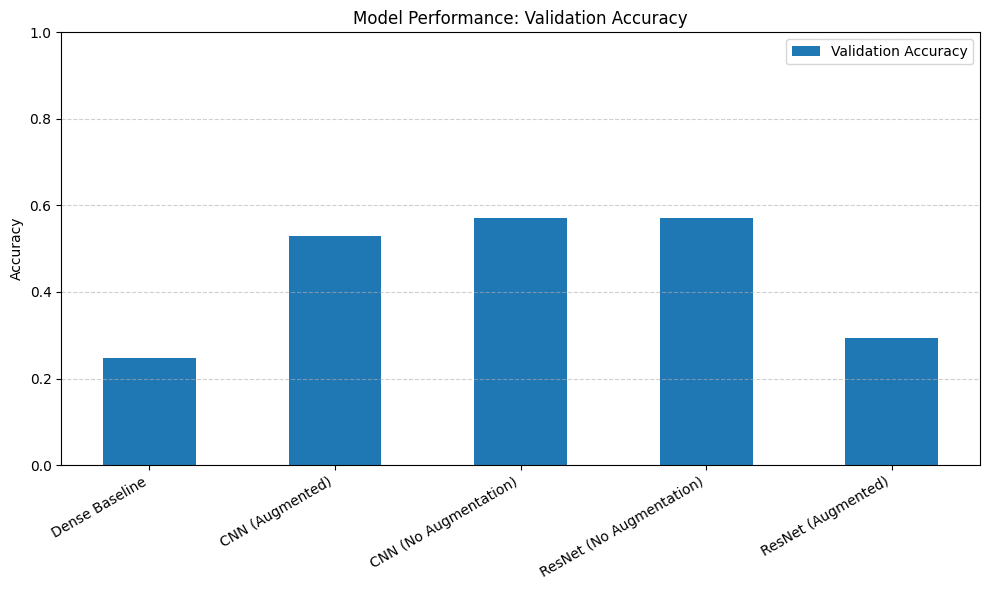


--- Final Validation Accuracies ---
Dense Baseline: Val=0.2473
CNN (Augmented): Val=0.5302
CNN (No Augmentation): Val=0.5709
ResNet (No Augmentation): Val=0.5719
ResNet (Augmented): Val=0.2944


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# -----------------------------
# Helper: get final val accuracy (and train if history is available)
# -----------------------------
def get_final_acc(label, history_name, model_file, train_gen, val_gen):
    data = {'label': label, 'train_acc': None, 'val_acc': None}

    # If history exists in memory, use its last values (cheap)
    if history_name in globals() and hasattr(globals()[history_name], 'history'):
        hist = globals()[history_name].history
        data['train_acc'] = hist.get('accuracy', [None])[-1]
        data['val_acc'] = hist.get('val_accuracy', [None])[-1]
        return data

    # Otherwise, load model and only evaluate on validation set (fast-ish)
    if os.path.exists(model_file):
        model = load_model(model_file)
        val_loss, val_acc = model.evaluate(val_gen, verbose=0)
        data['val_acc'] = val_acc
        return data

    print(f"Warning: No history or file for {label}")
    return None


# -----------------------------
# Targets
# -----------------------------
targets = [
    {
        'label': 'Dense Baseline',
        'history_name': 'history_dense',
        'model_file': 'model_dense.keras',
        'train_gen': train_generator_gray,
        'val_gen': validation_generator_gray
    },
    {
        'label': 'CNN (Augmented)',
        'history_name': 'history_cnn',
        'model_file': 'model_cnn.keras',
        'train_gen': train_generator_gray,
        'val_gen': validation_generator_gray
    },
    {
        'label': 'CNN (No Augmentation)',
        'history_name': 'history_cnn_no_aug',
        'model_file': 'model_cnn_no_aug.keras',
        'train_gen': train_generator_gray_no_aug,
        'val_gen': validation_generator_gray_no_aug
    },
    {
        'label': 'ResNet (No Augmentation)',
        'history_name': 'history_resnet_1e3_no_aug',
        'model_file': 'best_model_resnet.keras',
        'train_gen': train_generator_rgb_no_aug,
        'val_gen': validation_generator_rgb_no_aug
    },
    {
        'label': 'ResNet (Augmented)',
        'history_name': 'history_resnet_1e3_aug',
        'model_file': 'best_model_resnet_aug.keras',
        'train_gen': train_generator_rgb,
        'val_gen': validation_generator_rgb
    }
]

# -----------------------------
# Collect final metrics
# -----------------------------
results = [get_final_acc(**t) for t in targets]
results = [r for r in results if r is not None]

labels = [r['label'] for r in results]
val_accs = [r['val_acc'] for r in results]

x = np.arange(len(labels))
width = 0.5

plt.figure(figsize=(10, 6))
plt.bar(x, val_accs, width, label='Validation Accuracy')

plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Accuracy')
plt.title('Model Performance: Validation Accuracy')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Final Validation Accuracies ---")
for r in results:
    print(f"{r['label']}: Val={r['val_acc']:.4f}")


## Model Evaluation
Defining utility functions to plot Confusion Matrices and evaluate model performance.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

def plot_conf_matrix(model_file, test_gen, label, normalize=True):
    print(f"\nEvaluating: {label}")

    # Load model
    model = load_model(model_file)

    # Predict on the test generator
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # Compute confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize='true' if normalize else None
    )

    # Plot
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(test_gen.class_indices.keys())
    )
    disp.plot(cmap='Blues', xticks_rotation=45, values_format=".2f")
    plt.title(f'Confusion Matrix — {label}')
    plt.tight_layout()
    plt.show()



Evaluating: Dense Baseline


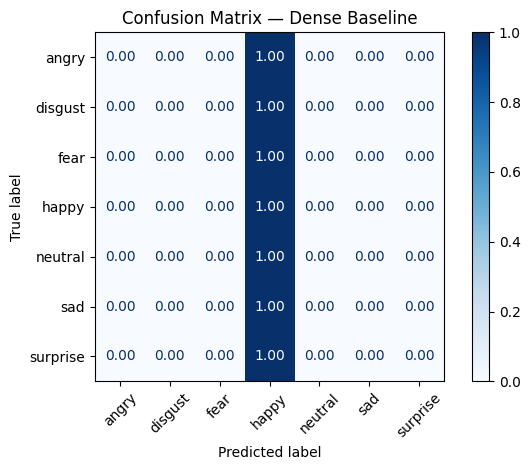


Evaluating: CNN (Augmented)


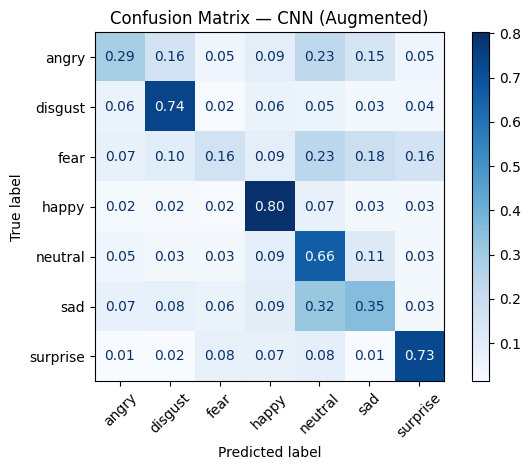


Evaluating: CNN (No Augmentation)


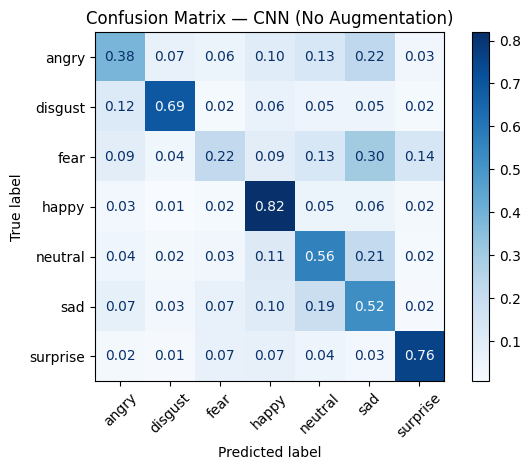


Evaluating: ResNet (No Augmentation)


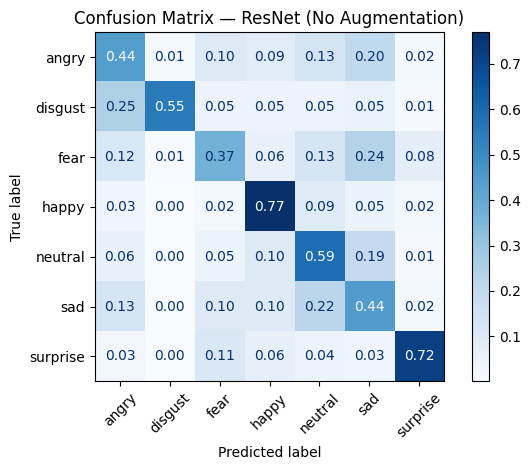


Evaluating: ResNet (Augmented)


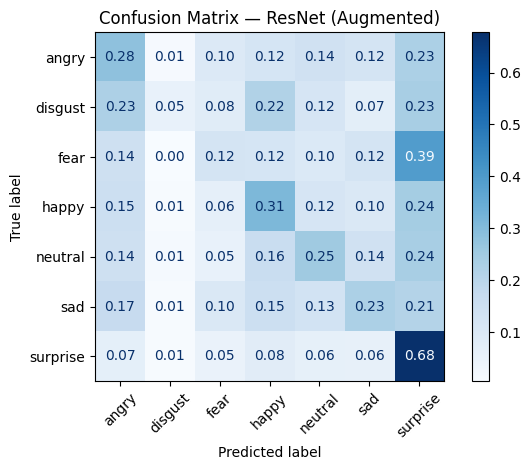

In [ ]:
# Dense + CNN use grayscale test generator with augmentation
plot_conf_matrix("model_dense.keras",
                 validation_generator_gray,
                 "Dense Baseline")

plot_conf_matrix("model_cnn.keras",
                 validation_generator_gray,
                 "CNN (Augmented)")

# CNN (No Augmentation): grayscale no-aug test generator
plot_conf_matrix("model_cnn_no_aug.keras",
                 validation_generator_gray_no_aug,
                 "CNN (No Augmentation)")

# ResNet (No Augmentation): RGB no-aug test generator
plot_conf_matrix("best_model_resnet.keras",
                 validation_generator_rgb_no_aug,
                 "ResNet (No Augmentation)")

# ResNet (Augmented): RGB test generator with augmentation settings
plot_conf_matrix("best_model_resnet_aug.keras",
                 validation_generator_rgb,
                 "ResNet (Augmented)")
